Load data

In [44]:
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt

X = [[0],[1],[2],[3],[4],[5],[6],[7],[8],[9],[10],[11],[12],[13],[14],[15],[16],[17],[18],[19],[20],[21],[22],[23],[24]]
y_true = [0,0,0,0,0,1,1,0,1,0,1,0,0,1,1,0,1,1,1,1,1,1,1,1,1]
thresholds = np.arange(0.0, 1.0, 1/25)


In [45]:
# print(X[0])
# print(y.shape)

Train the model

In [50]:
model = LogisticRegression()
model.fit(X, y_true)

probs = model.predict_proba(X)[:, 1]  # probability of class 1

print(probs)

[0.08424056 0.1063277  0.13336254 0.16599446 0.20472477 0.24978526
 0.30100976 0.35773001 0.41873552 0.48233173 0.54650553 0.60917012
 0.66842918 0.72279191 0.77129126 0.81349483 0.8494309  0.87946868
 0.90418998 0.92427743 0.94043083 0.95331239 0.96351643 0.97155682
 0.97786595]


In [51]:
def confusion_counts(y_true, y_pred):
    if len(y_true) != len(y_pred):
        raise ValueError("Arrays must have the same length")

    TP = TN = FP = FN = 0

    for t, p in zip(y_true, y_pred):
        if t == 1 and p == 1:
            TP += 1
        elif t == 0 and p == 0:
            TN += 1
        elif t == 0 and p == 1:
            FP += 1
        elif t == 1 and p == 0:
            FN += 1

    return TP, TN, FP, FN

tp = []
fp = []

for t in thresholds:
    y_pred_custom = (probs >= t).astype(int)
    TP, TN, FP, FN = confusion_counts(y_true, y_pred_custom)
    TPR = TP / (TP + FN)
    FPR = FP / (FP + TN)  #Sensitivity
    fp.append(FPR)
    tp.append(TPR)

In [53]:
def compute_auc(fpr, tpr):
    auc = 0.0
    for i in range(1, len(fpr)):
        auc += (fpr[i] - fpr[i - 1]) * (tpr[i] + tpr[i - 1]) / 2
    return auc

[1.0, 1.0, 1.0, 0.8, 0.7, 0.6, 0.5, 0.5, 0.5, 0.4, 0.4, 0.4, 0.4, 0.3, 0.3, 0.3, 0.2, 0.1, 0.1, 0.1, 0.1, 0.0, 0.0, 0.0, 0.0]
[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9333333333333333, 0.8666666666666667, 0.8666666666666667, 0.8666666666666667, 0.8, 0.8, 0.8, 0.7333333333333333, 0.7333333333333333, 0.7333333333333333, 0.7333333333333333, 0.7333333333333333, 0.6666666666666666, 0.6, 0.6, 0.4666666666666667, 0.4, 0.2]


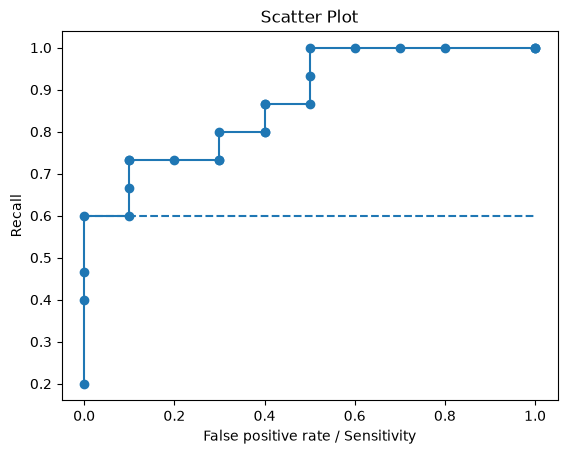

In [52]:
print(fp)
print(tp)
plt.plot(fp, tp, marker="o", label="PR curve")
baseline = np.mean(y_true)
plt.hlines(baseline, 0, 1, linestyles="--", label="Baseline")
plt.xlabel("False positive rate / Sensitivity")
plt.ylabel("Recall")
plt.title("Scatter Plot")
plt.show()

Compute auc

In [54]:
auc = compute_auc(fp,tp)

FPR: [1.0, 1.0, 1.0, 0.8, 0.7, 0.6, 0.5, 0.5, 0.5, 0.4, 0.4, 0.4, 0.4, 0.3, 0.3, 0.3, 0.2, 0.1, 0.1, 0.1, 0.1, 0.0, 0.0, 0.0, 0.0]
TPR: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9333333333333333, 0.8666666666666667, 0.8666666666666667, 0.8666666666666667, 0.8, 0.8, 0.8, 0.7333333333333333, 0.7333333333333333, 0.7333333333333333, 0.7333333333333333, 0.7333333333333333, 0.6666666666666666, 0.6, 0.6, 0.4666666666666667, 0.4, 0.2]
AUC: -0.8733333333333333


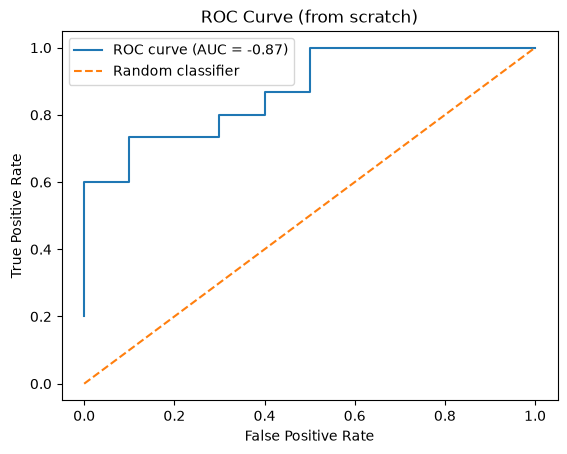

In [55]:
print("FPR:", fp)
print("TPR:", tp)
print("AUC:", auc)
plt.figure()
plt.plot(fp, tp, label=f"ROC curve (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (from scratch)")
plt.legend()